In [40]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import scipy.io as io
import argparse

import src.models.models as models
import src.training.self_supervision as ssl
import src.utils.utils as utils
import src.utils.extractor as extractor

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

False


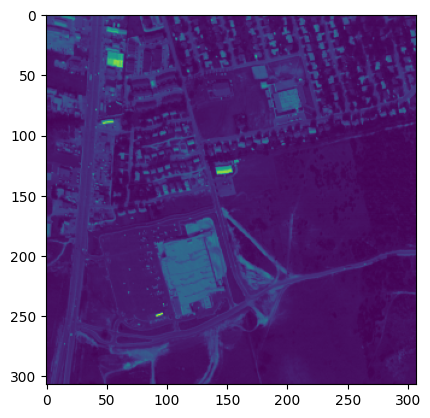

In [41]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y = torch.tensor(data["Y"])
Y = Y.to(torch.float32)
E = torch.tensor(data["E"])
B, c, N = E.shape[0], E.shape[1], Y.shape[1]

Y = Y.reshape(Y.shape[0], int(Y.shape[1]**0.5), int(Y.shape[1]**0.5))
H, W = Y.shape[1], Y.shape[2]

patch_size = 100

plt.imshow(Y.cpu()[10,:,:])

In [42]:
# dataset_full = utils.HSI_dataset(dataset=dataset)
# dataset_patched = utils.HSI_dataset(dataset=dataset, patch_size=patch_size)
# full_loader = DataLoader(dataset_full)
# patched_loader = DataLoader(dataset_patched)

full_loader, _, _ = utils.create_dataloader(dataset, dev)
patched_loader, test_loader, B, _ = utils.create_dataloader(dataset, dev, 0.7, patch_size)

## Models

### MLP AE ✅

In [43]:
mlpae = models.MLP_AE(B=B, c=c)
sum(p.numel() for p in mlpae.parameters() if p.requires_grad)

160044

### CNNAE + linear mapping ✅

In [44]:
cnnlinear = models.CNNAE_linear(B=B, c=c, patch_size=patch_size)
sum(p.numel() for p in cnnlinear.parameters() if p.requires_grad)

150642

### CNNAEU ✅

In [45]:
Y_init = next(iter(full_loader))[0][0]

In [46]:
cnnaeu = models.CNNAEU(B=B, c =c)
cnnaeu = models.init_decoder_weights(cnnaeu, Y_init, c, 11)
sum(p.numel() for p in cnnaeu.parameters() if p.requires_grad)

187992

### Transformer AE ✅
*Accepts higher patch sizes than CNN linear*

In [47]:
Y_trans = Y[:,:patch_size,:patch_size]
transformer_patched = models.Transformer_AE(B=B, c=c, im_size=Y_trans.shape[1], dim=200)
transformer_patched = models.init_decoder_weights(transformer_patched, Y_init, c)
sum(p.numel() for p in transformer_patched.parameters() if p.requires_grad)

14125646

### NALMU ✅

In [48]:
nalmu_full = models.NALMU(B=B, c=c, N=N)
nalmu_patched = models.NALMU(B=B, c=c, N=patch_size**2)
sum(p.numel() for p in nalmu_full.parameters() if p.requires_grad)

5664660

### RALMU ✅

In [49]:
ralmu_full = models.RALMU(B=B, c=c, im_size=H)
ralmu_patched = models.RALMU(B=B, c=c, im_size=patch_size)
sum(p.numel() for p in ralmu_full.parameters() if p.requires_grad)

2274170

## SSL methods

In [50]:
model = transformer_patched
epochs = 100
lr = 1e-2

### Reconstruction error

Saved permanent model Transformer_AE_RE_lr_0.01_epoch_10.pt
Saved permanent model Transformer_AE_RE_lr_0.01_epoch_20.pt
Saved permanent model Transformer_AE_RE_lr_0.01_epoch_30.pt
Saved permanent model Transformer_AE_RE_lr_0.01_epoch_40.pt
Saved permanent model Transformer_AE_RE_lr_0.01_epoch_50.pt
Saved permanent model Transformer_AE_RE_lr_0.01_epoch_60.pt
Saved permanent model Transformer_AE_RE_lr_0.01_epoch_70.pt
Saved permanent model Transformer_AE_RE_lr_0.01_epoch_80.pt
Saved permanent model Transformer_AE_RE_lr_0.01_epoch_90.pt
torch.Size([162, 6]) torch.Size([1, 6, 10000])


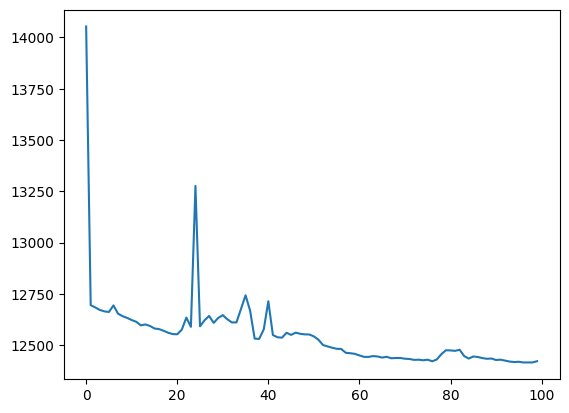

In [33]:
re_trainer = ssl.ReconstructionError(model, epochs=epochs, lr=lr)
e_hat_re, a_hat_re, train_losses_re = re_trainer.train(patched_loader)
print(e_hat_re.shape, a_hat_re.shape)

plt.plot(train_losses_re)

### DIP

torch.Size([162, 6]) torch.Size([1, 6, 94249])


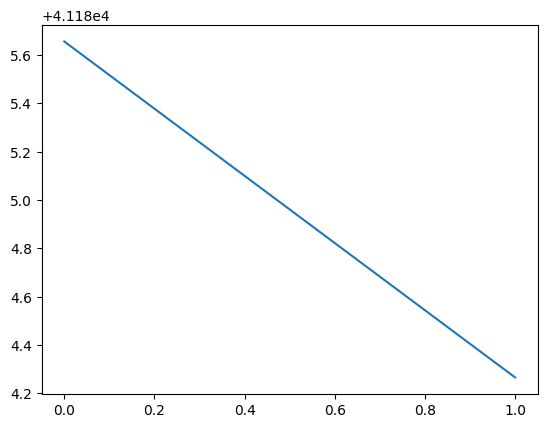

In [16]:
dip_trainer = ssl.DIP(model, epochs=epochs, lr=lr)
e_hat_dip, a_hat_dip, train_losses_dip = dip_trainer.train(full_loader)
print(e_hat_dip.shape, a_hat_dip.shape)

plt.plot(train_losses_dip)

### Two stages net

In [13]:
# two_s_trainer = ssl.TwoStagesNet(model, B, epochs=epochs, lr=lr)
# e_hat_twos, a_hat_twos, train_losses_twos = two_s_trainer.train(full_loader)
# print(e_hat_twos.shape, a_hat_twos.shape)

# plt.plot(train_losses_twos)

### Testing learned model:

In [38]:
next(iter(patched_loader))[0].shape

torch.Size([1, 162, 10000])

In [52]:
Y.shape

torch.Size([162, 94249])

In [53]:
model.load_state_dict(torch.load("models/Transformer_AE_RE_lr_0.01_epoch_90.pt")["model_state_dict"], strict=False)

Y = torch.tensor(data["Y"])
Y = Y.to(torch.float32)[:, :patch_size**2]


e_hat, a_hat, y_hat = model.forward(Y)
e_hat = extractor.normalize_endmembers(e_hat)

if e_hat.dim() == 3:
    e_hat = e_hat.squeeze(0)
    
# model = cnnaeu
# re, sad = utils.test_model(model, full_loader)
# print(re, sad)

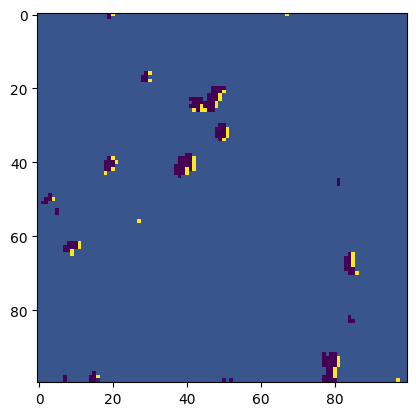

In [ ]:
"""
Display extracted abundance matrix
"""
plt.imshow(a_hat.reshape(a_hat.shape[1], int(a_hat.shape[2]**0.5), int(a_hat.shape[2]**0.5))[0].detach())

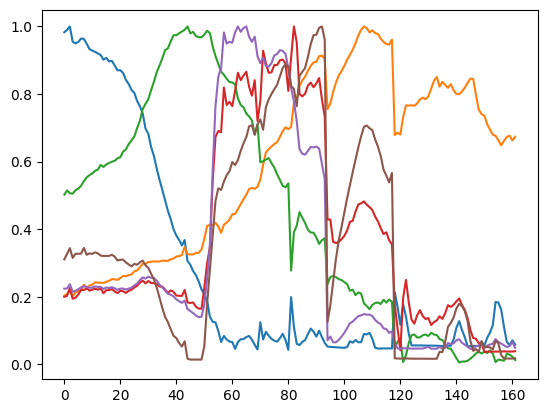

In [55]:
"""
Display extracted endmembers
"""
for i in range(c):
    plt.plot(e_hat[:,i].detach())
plt.show()